# HW2 – scikit-learn 套件執行

本 Notebook 會輸出：
- 三群資料散點圖
- 每個模型的 **訓練/測試正確率**
- 每個模型的 **決策區域**


In [ ]:
#安裝 scikit-learn

In [ ]:
import sys
!{sys.executable} -m pip install -U scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 1.5 MB/s eta 0:00:0000:0100:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 2.4 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 為了可重現（Resubmitable）
RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)


## 1) 亂數產生 3 群資料

使用 `make_blobs` 產生三群高斯團，並固定 random_state 以確保每次重跑結果一致。


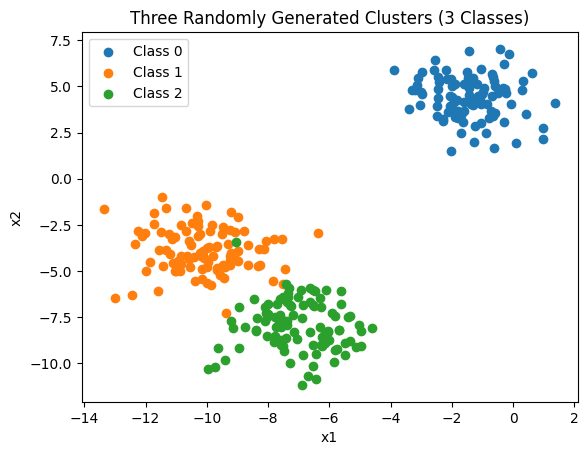

In [ ]:
X, y = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    cluster_std=1.2,
    random_state=RANDOM_STATE
)

# 切分訓練/測試
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# 資料視覺化
plt.figure()
for cls in np.unique(y):
    plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f'Class {cls}')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Three Randomly Generated Clusters (3 Classes)')
plt.legend()
plt.show()


In [ ]:
# HW2 – scikit-learn 套件執行

In [ ]:
def plot_decision_regions(X, y, classifier, resolution=0.02, title='Decision Regions'):
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution)
    )
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    Z = classifier.predict(grid).reshape(xx1.shape)

    plt.figure()
    plt.contourf(xx1, xx2, Z, alpha=0.2)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    for cls in np.unique(y):
        plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f'Class {cls}')
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.show()

## ２) (1) 邏輯斯迴歸

- 使用 `LogisticRegression(multi_class='ovr')` 進行三分類  
- 由於 LR 對特徵尺度較敏感，使用 `StandardScaler` 進行標準化


Logistic Regression
  Train Accuracy: 0.9857142857142858
  Test  Accuracy: 0.9666666666666667


/Users/chouyouzhen/.pyenv/versions/3.10.12/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


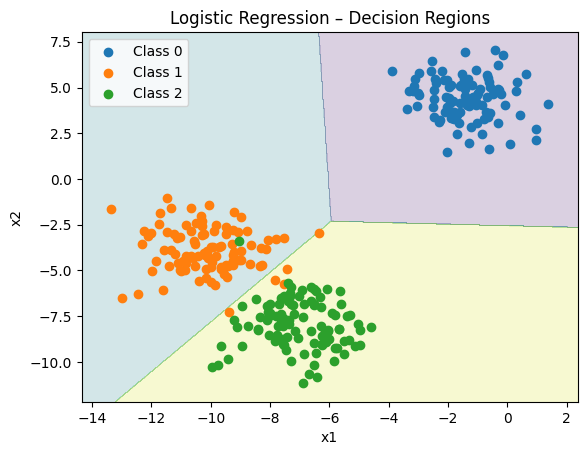

In [ ]:
lr_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        multi_class='ovr',
        solver='lbfgs',
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    )
)

lr_clf.fit(X_train, y_train)

y_pred_train = lr_clf.predict(X_train)
y_pred_test  = lr_clf.predict(X_test)

print('Logistic Regression')
print('  Train Accuracy:', accuracy_score(y_train, y_pred_train))
print('  Test  Accuracy:', accuracy_score(y_test, y_pred_test))

plot_decision_regions(X, y, lr_clf, title='Logistic Regression – Decision Regions')


## ３) (2) 支援向量機

- 使用 RBF kernel 的 `SVC`（常見且效果穩定）  
- 同樣使用 `StandardScaler`（SVM 對尺度也敏感）


SVM (RBF Kernel)
  Train Accuracy: 0.9904761904761905
  Test  Accuracy: 0.9666666666666667


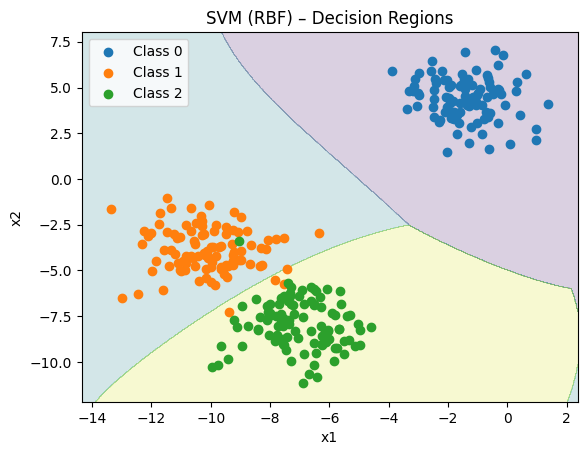

In [ ]:
svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
)

svm_clf.fit(X_train, y_train)

y_pred_train = svm_clf.predict(X_train)
y_pred_test  = svm_clf.predict(X_test)

print('SVM (RBF Kernel)')
print('  Train Accuracy:', accuracy_score(y_train, y_pred_train))
print('  Test  Accuracy:', accuracy_score(y_test, y_pred_test))

plot_decision_regions(X, y, svm_clf, title='SVM (RBF) – Decision Regions')


## 4) (3) 決策樹 

- 使用 `DecisionTreeClassifier`  
- 決策樹不需要標準化（對尺度不敏感）


Decision Tree
  Train Accuracy: 1.0
  Test  Accuracy: 0.9777777777777777


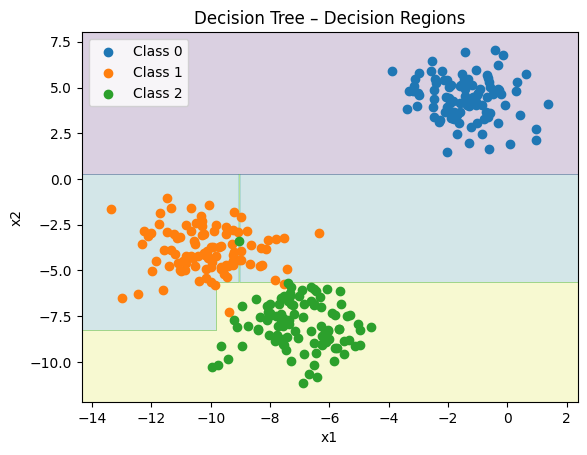

In [ ]:
tree_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=RANDOM_STATE
)

tree_clf.fit(X_train, y_train)

y_pred_train = tree_clf.predict(X_train)
y_pred_test  = tree_clf.predict(X_test)

print('Decision Tree')
print('  Train Accuracy:', accuracy_score(y_train, y_pred_train))
print('  Test  Accuracy:', accuracy_score(y_test, y_pred_test))

plot_decision_regions(X, y, tree_clf, title='Decision Tree – Decision Regions')
